In [1]:
import pandas as pd

import os, sys
import matplotlib.pyplot as plt

sys.path.insert(0, "../../")

from spec.enums import MainTableColumns as Cols

In [2]:
# base_dir = '../../../sample_data/cwo/s19/analysis/'
base_dir = '../../../sample_data/cwo/f19/analysis/'
# base_dir = '../../../sample_data/codebench/2024/analysis/'

In [3]:
data = pd.read_csv(os.path.join(base_dir, 'subject_features.csv'))

In [4]:
data.head()

,SubjectID,ActiveTime_mean,PassiveTime_mean,TotalTime_mean,ActiveTimeAfterCorrect_mean,#Breaks_mean,StartTime_mean,FirstCorrectTime_mean,EndTime_mean,Attempts_mean,...,Attempts_sum,FirstCorrect_sum,EverCorrect_sum,Attempted_sum,MaxScore_sum,MinScore_sum,MeanScore_sum,TotalAttempts_sum,ErrorQuotient_sum,Grade
0,00358c94503a8d9e6869efc6e5cdb0e1c8e9eb39b1fd46...,-0.685563,0.484128,-0.076271,-0.352424,-0.676169,-0.839142,0.396054,-0.926054,-0.685246,...,-0.705124,0.454054,0.442892,0.188284,0.378577,0.152977,0.153765,-0.735522,0.064376,59.38
1,014604ba54339d4b1266cf78e125053a5ac11dd861ef3c...,-0.991404,-0.217950,-0.645203,-0.261632,2.240611,0.358333,0.396265,0.420566,-0.671285,...,-0.690676,0.454054,0.442892,0.188284,0.378577,0.210255,0.315779,-0.661867,-1.481635,97.00
2,01e96e066eff2e82627dac0493737be2de9bd2f50d6d49...,-0.513237,-0.088756,-0.308663,-0.338911,-0.650882,-0.320927,-0.582847,-0.383971,-0.472262,...,-0.436229,-0.030653,-1.014217,-0.522700,-0.280984,-0.088951,0.092827,-0.467155,-0.211719,59.46
3,03000c72d4dd6a4be44ffc175dec5d9a15a83a2f8073b0...,0.282839,1.182794,0.822134,0.114648,0.833342,-0.245824,0.175692,-0.191294,-0.048258,...,-0.045881,0.938761,0.151470,0.188284,0.231486,1.358611,1.208508,0.031435,-0.996724,73.05
4,0461c96c9cc0058f709704605f24136f373ba4e9ac083a...,0.720015,-0.628277,0.025084,-0.345641,0.215532,-3.107647,0.200982,-3.012465,-0.172449,...,-0.165691,-0.757714,-0.139952,-0.167208,0.155142,-0.091190,0.200624,-0.205600,-0.488088,73.13


In [5]:
X = data.drop(columns=[Cols.SubjectID, 'Grade'])
y = data['Grade']

In [6]:
# Drop columns with 0 variance
variance = X.var()
zero_variance_cols = variance[variance == 0].index
print (f"Dropping columns with zero variance: {zero_variance_cols.tolist()}")
X = X.drop(columns=zero_variance_cols)

Dropping columns with zero variance: ['Attempted_mean']


In [7]:
linear_corr = X.corr()
# Find pairs that have correlation above 0.9
corr_pairs = linear_corr[linear_corr != 1].stack().reset_index()
corr_pairs.columns = ['Feature1', 'Feature2', 'Correlation']
high_corr_pairs = corr_pairs[abs(corr_pairs['Correlation']) > 0.9].reset_index(drop=True)
print("High correlation pairs:")
with pd.option_context('display.max_rows', None):
    print(high_corr_pairs)

High correlation pairs:
                       Feature1                     Feature2  Correlation
0               ActiveTime_mean                Attempts_mean     0.952991
1               ActiveTime_mean           TotalAttempts_mean     0.950086
2               ActiveTime_mean               ActiveTime_sum     0.987114
3               ActiveTime_mean                 Attempts_sum     0.941685
4               ActiveTime_mean            TotalAttempts_sum     0.938390
5              PassiveTime_mean               TotalTime_mean     0.908589
6              PassiveTime_mean              PassiveTime_sum     0.979592
7                TotalTime_mean             PassiveTime_mean     0.908589
8                TotalTime_mean              PassiveTime_sum     0.900423
9                TotalTime_mean                TotalTime_sum     0.982258
10  ActiveTimeAfterCorrect_mean   ActiveTimeAfterCorrect_sum     0.986636
11                 #Breaks_mean                  #Breaks_sum     0.993455
12            

<Axes: >

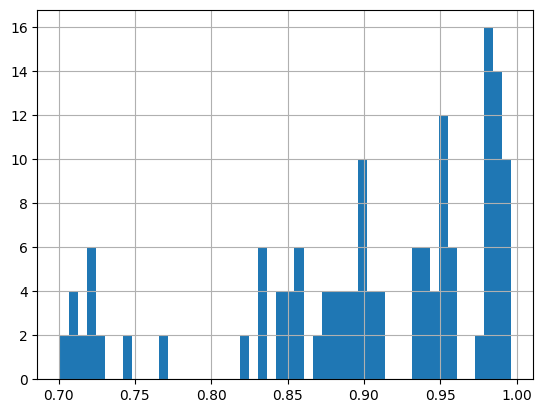

In [8]:
corr_pairs.Correlation[corr_pairs.Correlation > 0.7].hist(bins=50)

In [9]:
# For each highly correlated pair of features, drop the one with the lower
# correlation with the target variable
def drop_low_corr_feature(pair, X, y):
    feature1, feature2 = pair['Feature1'], pair['Feature2']
    corr1 = X[feature1].corr(y)
    corr2 = X[feature2].corr(y)
    if abs(corr1) > abs(corr2):
        return feature2
    else:
        return feature1

to_drop = high_corr_pairs.apply(drop_low_corr_feature, axis=1, X=X, y=y)
print(f"Dropping features with high correlation: {to_drop.tolist()}")
X_lean = X.drop(columns=to_drop)

Dropping features with high correlation: ['Attempts_mean', 'ActiveTime_mean', 'ActiveTime_mean', 'ActiveTime_mean', 'ActiveTime_mean', 'PassiveTime_mean', 'PassiveTime_sum', 'PassiveTime_mean', 'PassiveTime_sum', 'TotalTime_mean', 'ActiveTimeAfterCorrect_mean', '#Breaks_mean', 'StartTime_mean', 'StartTime_mean', 'StartTime_mean', 'EverCorrect_mean', 'FirstCorrectTime_sum', 'StartTime_mean', 'StartTime_sum', 'EndTime_mean', 'Attempts_mean', 'Attempts_mean', 'Attempts_mean', 'Attempts_mean', 'Attempts_mean', 'MinScore_mean', 'FirstCorrect_sum', 'MinScore_sum', 'EverCorrect_mean', 'MinScore_mean', 'MinScore_mean', 'MinScore_mean', 'MinScore_mean', 'MinScore_mean', 'MinScore_mean', 'MinScore_sum', 'MeanScore_sum', 'ActiveTime_mean', 'Attempts_mean', 'TotalAttempts_mean', 'Attempts_sum', 'TotalAttempts_mean', 'ErrorQuotient_mean', 'ActiveTime_mean', 'Attempts_mean', 'TotalAttempts_mean', 'ActiveTime_sum', 'Attempts_sum', 'ActiveTime_sum', 'PassiveTime_sum', 'PassiveTime_sum', 'PassiveTime_s

In [10]:
X_lean.columns

Index(['FirstCorrectTime_mean', 'FirstCorrect_mean', 'MaxScore_mean',
       'MeanScore_mean', 'TotalTime_sum', 'ActiveTimeAfterCorrect_sum',
       '#Breaks_sum', 'EndTime_sum', 'EverCorrect_sum', 'Attempted_sum',
       'MaxScore_sum', 'TotalAttempts_sum', 'ErrorQuotient_sum'],
      dtype='object')

In [ ]:
# Use the original data to peak at Grade
data.drop(columns=to_drop).drop(columns=[Cols.SubjectID]).corr(method='spearman')

,FirstCorrectTime_mean,FirstCorrect_mean,Attempted_mean,MaxScore_mean,MeanScore_mean,TotalTime_sum,ActiveTimeAfterCorrect_sum,#Breaks_sum,EndTime_sum,EverCorrect_sum,Attempted_sum,MaxScore_sum,TotalAttempts_sum,ErrorQuotient_sum,Grade
FirstCorrectTime_mean,1.000000,0.279646,NaN,0.878028,0.315482,-0.220126,0.004845,-0.214100,0.218726,0.783281,0.263406,0.863391,-0.223487,-0.223393,-0.008814
FirstCorrect_mean,0.279646,1.000000,NaN,0.272031,0.890638,-0.672650,-0.133336,-0.518080,-0.024529,0.243652,0.087682,0.264204,-0.757050,-0.635821,-0.004855
Attempted_mean,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
MaxScore_mean,0.878028,0.272031,NaN,1.000000,0.330818,-0.224264,0.015932,-0.226572,-0.087390,0.815126,0.249563,0.954878,-0.218966,-0.225101,0.075204
MeanScore_mean,0.315482,0.890638,NaN,0.330818,1.000000,-0.764668,-0.184261,-0.576059,-0.075277,0.305990,0.162267,0.319994,-0.842350,-0.851628,0.126390
TotalTime_sum,-0.220126,-0.672650,NaN,-0.224264,-0.764668,1.000000,0.249983,0.666272,0.039026,-0.227760,-0.115802,-0.231455,0.894901,0.678539,-0.133483
ActiveTimeAfterCorrect_sum,0.004845,-0.133336,NaN,0.015932,-0.184261,0.249983,1.000000,0.211197,0.041717,-0.056732,-0.238107,-0.009326,0.322944,0.234080,-0.161239
#Breaks_sum,-0.214100,-0.518080,NaN,-0.226572,-0.576059,0.666272,0.211197,1.000000,0.010433,-0.223490,-0.093347,-0.226412,0.650782,0.470654,-0.111325
EndTime_sum,0.218726,-0.024529,NaN,-0.087390,-0.075277,0.039026,0.041717,0.010433,1.000000,-0.139299,-0.152606,-0.092121,0.040596,0.098909,-0.262865
EverCorrect_sum,0.783281,0.243652,NaN,0.815126,0.305990,-0.227760,-0.056732,-0.223490,-0.139299,1.000000,0.608057,0.899935,-0.220027,-0.252247,0.119375


In [25]:
from sklearn.ensemble import RandomForestRegressor

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X_lean, y, test_size=0.25, random_state=42)

In [46]:
from sklearn.model_selection import GridSearchCV
param_grid = {
    # 'n_estimators': [50, 100, 200, 350, 500],
    'n_estimators': [10, 20, 50, 100, 200],
    'max_depth': [1, 5, 10, 20, 30],
}

rf = RandomForestRegressor(random_state=42)
grid_search = GridSearchCV(rf, param_grid, cv=5, scoring='neg_mean_absolute_error')

grid_search.fit(X_train, y_train)
print("Best parameters found: ", grid_search.best_params_)

Best parameters found:  {'max_depth': 5, 'n_estimators': 200}


In [47]:
pd.DataFrame(grid_search.cv_results_)[["mean_test_score", "std_test_score", "params"]]

,mean_test_score,std_test_score,params
0,-14.090895,1.144111,"{'max_depth': 1, 'n_estimators': 10}"
1,-14.151086,1.059485,"{'max_depth': 1, 'n_estimators': 20}"
2,-14.160320,1.016885,"{'max_depth': 1, 'n_estimators': 50}"
3,-14.068914,1.028248,"{'max_depth': 1, 'n_estimators': 100}"
4,-14.059586,1.015591,"{'max_depth': 1, 'n_estimators': 200}"
5,-13.356197,1.265009,"{'max_depth': 5, 'n_estimators': 10}"
6,-13.236290,1.112117,"{'max_depth': 5, 'n_estimators': 20}"
7,-13.020626,1.042167,"{'max_depth': 5, 'n_estimators': 50}"
8,-13.019980,0.995007,"{'max_depth': 5, 'n_estimators': 100}"
9,-12.983126,0.978109,"{'max_depth': 5, 'n_estimators': 200}"


In [53]:
from sklearn.linear_model import LassoCV

lasso = LassoCV(cv=5, random_state=42)
lasso.fit(X_train, y_train)

# Create a table of each feature and its coefficient
lasso_coef = pd.DataFrame({
    'Feature': X_train.columns,
    'Coefficient': lasso.coef_,
    'Abs_Coefficient': abs(lasso.coef_)
})
lasso_coef.sort_values(by='Abs_Coefficient', ascending=False)


,Feature,Coefficient,Abs_Coefficient
1,FirstCorrect_mean,-7.923847,7.923847
12,ErrorQuotient_sum,-5.839465,5.839465
0,FirstCorrectTime_mean,4.373688,4.373688
7,EndTime_sum,-3.003334,3.003334
4,TotalTime_sum,-1.679180,1.679180
10,MaxScore_sum,-1.653838,1.653838
5,ActiveTimeAfterCorrect_sum,-1.307318,1.307318
11,TotalAttempts_sum,-1.106925,1.106925
6,#Breaks_sum,-0.541734,0.541734
3,MeanScore_mean,-0.000000,0.000000


In [59]:
from sklearn.ensemble import GradientBoostingRegressor
gb = GradientBoostingRegressor(random_state=42)
param_grid = {
    'n_estimators': [50, 100, 200],
    'learning_rate': [0.01, 0.1, 0.2],
    'max_depth': [3, 5, 7],
}
gb_grid_search = GridSearchCV(gb, param_grid, cv=5, scoring='neg_mean_absolute_error')
gb_grid_search.fit(X_train, y_train)

,estimator,GradientBoost...ndom_state=42)
,param_grid,"{'learning_rate': [0.01, 0.1, ...], 'max_depth': [3, 5, ...], 'n_estimators': [50, 100, ...]}"
,scoring,'neg_mean_absolute_error'
,n_jobs,None
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,loss,'squared_error'


In [60]:
pd.DataFrame(gb_grid_search.cv_results_)[["mean_test_score", "std_test_score", "params"]]

,mean_test_score,std_test_score,params
0,-14.070226,1.026319,"{'learning_rate': 0.01, 'max_depth': 3, 'n_est..."
1,-13.694874,1.057721,"{'learning_rate': 0.01, 'max_depth': 3, 'n_est..."
2,-13.323236,1.149085,"{'learning_rate': 0.01, 'max_depth': 3, 'n_est..."
3,-14.058691,0.918846,"{'learning_rate': 0.01, 'max_depth': 5, 'n_est..."
4,-13.669812,0.815984,"{'learning_rate': 0.01, 'max_depth': 5, 'n_est..."
5,-13.401350,0.738296,"{'learning_rate': 0.01, 'max_depth': 5, 'n_est..."
6,-14.270673,1.045810,"{'learning_rate': 0.01, 'max_depth': 7, 'n_est..."
7,-14.021896,1.048530,"{'learning_rate': 0.01, 'max_depth': 7, 'n_est..."
8,-14.102301,1.022204,"{'learning_rate': 0.01, 'max_depth': 7, 'n_est..."
9,-13.492725,1.089331,"{'learning_rate': 0.1, 'max_depth': 3, 'n_esti..."


In [55]:
from sklearn.metrics import mean_absolute_error, r2_score

print(mean_absolute_error(y_test, grid_search.predict(X_test)))
print(r2_score(y_test, grid_search.predict(X_test)))

12.786316996246326
0.1361061260220442


In [57]:
print(mean_absolute_error(y_test, lasso.predict(X_test)))
print(r2_score(y_test, lasso.predict(X_test)))

12.146115403361572
0.24418398140039166


In [61]:
print(mean_absolute_error(y_test, gb_grid_search.predict(X_test)))
print(r2_score(y_test, gb_grid_search.predict(X_test)))

12.766240969189655
0.16509006139178561


In [58]:
from sklearn.dummy import DummyRegressor

dummy_regressor = DummyRegressor(strategy='mean')
dummy_regressor.fit(X_train, y_train)

print(mean_absolute_error(y_test, dummy_regressor.predict(X_test)))
print(r2_score(y_test, dummy_regressor.predict(X_test)))

14.168306451612905
-0.0027015809151533787


<Axes: >

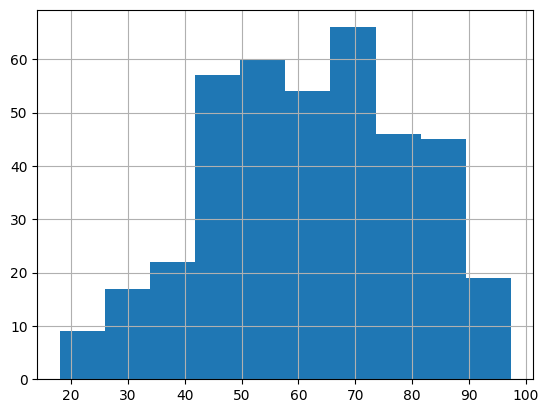

In [123]:
y_train.hist()